# Checking entity counts between Platform data, historic endpoints and transformed resources
**Author**:  Sian Teesdale

**Date created**: May 2026

**Dataset Scope**: article-4-direction-area, conservation-area, listed-building-outline, tree, tree-preservation-zone

**Purpose**: This analysis is to make a comparison report on the entity counts within the Platform and the entity_counts from the dataset_resource. The aim is for us to easily see if there are weird differences that could be a result of us duplicating data on the platform. 

In [1]:
import pandas as pd
import numpy as np
import json
import urllib.request
import matplotlib.pyplot as plt

## Process the reporting historic endpoint/dataset resource

In [2]:
# Save ODP datasets
datasets = ['article-4-direction-area', 'tree', 'tree-preservation-zone', 'listed-building-outline', 'conservation-area']

In [3]:
all_rows = []
last_rowid = 0

while True:
    if last_rowid == 0:
        # First batch: no filter
        url = "https://datasette.planning.data.gov.uk/performance/reporting_historic_endpoints.json?_shape=array&_size=max"
    else:
        # Subsequent batches: filter by rowid__gt
        url = f"https://datasette.planning.data.gov.uk/performance/reporting_historic_endpoints.json?_shape=array&_size=max&rowid__gt={last_rowid}"
    
    response = urllib.request.urlopen(url, timeout=120)
    rows = json.load(response)
    
    if not rows:
        break
    
    all_rows.extend(rows)
    last_rowid = rows[-1]['rowid']
    print(f"Fetched {len(all_rows)} rows...")
    
    if len(rows) < 1000:
        break

report_he = pd.DataFrame(all_rows)
print(f"Total: {len(report_he)} rows")


Fetched 1000 rows...
Fetched 2000 rows...
Fetched 3000 rows...
Fetched 4000 rows...
Fetched 5000 rows...
Fetched 6000 rows...
Fetched 7000 rows...
Fetched 8000 rows...
Fetched 9000 rows...
Fetched 10000 rows...
Fetched 11000 rows...
Fetched 12000 rows...
Fetched 13000 rows...
Fetched 14000 rows...
Fetched 15000 rows...
Fetched 16000 rows...
Fetched 17000 rows...
Fetched 18000 rows...
Fetched 19000 rows...
Fetched 20000 rows...
Fetched 21000 rows...
Fetched 22000 rows...
Fetched 23000 rows...
Fetched 24000 rows...
Fetched 25000 rows...
Fetched 26000 rows...
Fetched 27000 rows...
Fetched 27765 rows...
Total: 27765 rows


In [4]:
# Remove inactive endpoints and filter for only the ODP datasets 
report_he = report_he.loc[(report_he['dataset'].isin(datasets)) & (report_he['resource_end_date'] == '')]

# WARNING: merging `report_he` directly to `data_resource` can inflate counts
# if `report_he` contains multiple rows for the same resource. In that case
# the same dataset_resource.entity_count is repeated and then summed more than once.
#
# To avoid that, reduce `report_he` to one row per resource before the merge.
report_he = report_he.drop_duplicates(subset=['resource', 'dataset']).copy()

In [5]:
report_he.loc[(report_he['dataset'] == 'article-4-direction-area') & (report_he['name'] == 'London Borough of Barking and Dagenham')]['resource'].item()

'e3eb3651fdb452b7396dbf901df1f54324971d25b71355e6a5f13309a69dfc81'

In [6]:
# Loop over and get the dataset_resource for each dataset, then concatenate into a single dataframe
dfs = []
for data in datasets:
    df = pd.read_csv(f'https://datasette.planning.data.gov.uk/{data}/dataset_resource.csv?_stream=on')
    dfs.append(df)

data_resource = pd.concat(dfs)

In [7]:
testing = pd.merge(report_he, data_resource[['dataset', 'resource', 'entity_count', 'entry_count', 'line_count']], on=['dataset', 'resource'])

# Groupby to get entity-count per LPA
dataset_resource_entity_count = testing.groupby(['dataset', 'name', 'organisation'])[['entity_count', 'entry_count', 'line_count']].sum().reset_index()

In [8]:
# Get the entity and resource counts per LPA in each dataset
entity_resource_counts = testing.groupby(['dataset', 'name', 'organisation'])[['endpoint', 'resource']].count().reset_index()

In [ ]:
# Check Barnet has the duplicated resource for both Tree and TPZ (which is correct)
testing.loc[testing['name'].str.contains('Barnet')]

,rowid,organisation,name,organisation_name,dataset,collection,pipeline,endpoint,endpoint_url,documentation_url,...,latest_exception,resource,latest_log_entry_date,endpoint_entry_date,endpoint_end_date,resource_start_date,resource_end_date,entity_count,entry_count,line_count
215,9552,local-authority:BNE,London Borough of Barnet,London Borough of Barnet,article-4-direction-area,article-4-direction,article-4-direction-area,d4c09389082ca55e33cf532eb045ea7eb9dc447a24547f...,https://open.barnet.gov.uk/download/e5l77/dhv/...,https://open.barnet.gov.uk/dataset/e5l77/artic...,...,,2702f238b05ec028cbd33738b718a81ba9fc70680f1e6f...,2026-05-21,2023-12-18,,2024-07-17,,48.0,48,49
216,9575,local-authority:BNE,London Borough of Barnet,London Borough of Barnet,conservation-area,conservation-area,conservation-area,1cafec4102c43a9e95f54bd36453240251c7741d7d15de...,https://open.barnet.gov.uk/download/20yo8/c6n/...,https://open.barnet.gov.uk/dataset/20yo8/conse...,...,,622b7161f695d63420100a288b72d11b7113ca5e987e79...,2026-05-21,2023-11-06,,2025-03-21,,16.0,16,17
217,9584,local-authority:BNE,London Borough of Barnet,London Borough of Barnet,listed-building-outline,listed-building,listed-building-outline,6cec4fa5b9e9340c4f594bbdbac5cd7ffaf94498583d1c...,https://open.barnet.gov.uk/download/2w6jz/ztc/...,https://open.barnet.gov.uk/dataset/2w6jz/statu...,...,,1fb9fa7a23719e76fc5f55971d2ffa95e92fc705a0450a...,2026-05-21,2023-12-18,,2026-05-02,,651.0,651,652
218,9613,local-authority:BNE,London Borough of Barnet,London Borough of Barnet,tree,tree-preservation-order,tree,422e2a9f2fb1d809d8849e05556aa7c232060673c1cc51...,https://open.barnet.gov.uk/download/e5nge/837/...,https://open.barnet.gov.uk/dataset/e5nge/tree-...,...,,98681061fb9aca798fa2a294a2720ac97321c7ff5642e7...,2026-05-21,2023-11-07,,2026-05-02,,6181.0,6181,9392
219,9677,local-authority:BNE,London Borough of Barnet,London Borough of Barnet,tree-preservation-zone,tree-preservation-order,tree-preservation-zone,422e2a9f2fb1d809d8849e05556aa7c232060673c1cc51...,https://open.barnet.gov.uk/download/e5nge/837/...,https://open.barnet.gov.uk/dataset/e5nge/tree-...,...,,98681061fb9aca798fa2a294a2720ac97321c7ff5642e7...,2026-05-21,2023-11-07,,2026-05-02,,3210.0,3210,9392


In [ ]:
# Detailed endpoint/resource CSV 
detailed_dataset_resource_entity_count = testing.groupby(['dataset', 'name', 'organisation', 'endpoint', 'endpoint_entry_date', 'resource', 'resource_start_date'])[['entity_count', 'entry_count', 'line_count']].sum().reset_index()

# Save to CSV
detailed_dataset_resource_entity_count.to_csv('dataset_resource_odp_detailed_counts.csv', index=False)

In [ ]:
# How many resources appear more than once?
detailed_dataset_resource_entity_count['resource'].value_counts()

resource
ef2236d310cfdec35d754d13b8e4599d131102393e6bba716291ddb5cc993221    2
3c004d5128a298afc4960c5d74cbe16d55eb2eade6fe42b9b664be36a978ab89    2
98681061fb9aca798fa2a294a2720ac97321c7ff5642e7a64321bf1ab192c092    2
a15236ae19de583cf0782aa3df8cca5d74bcfb5c5c201c01ce70ab0671a8a2a6    2
66b6ee34f1666ef022ca9d52d7f12707d7b0b38ca1040b9c71a14d8d480bb58d    1
                                                                   ..
92c30cdae7169d831a3f52b3ffb2b877d5d562bb9bbe377e9f09353f03b0301b    1
2b5bc568417092f67af1ba67256614b153a6cbc589daa3545ff838838d253a7a    1
a0304351e90bfd06f7de89ccb7bd2c37cb2260fc53ab5e44b7f6a718cd29648a    1
3a706aa35784ec838a0635faf771c8d333f243d5bea9b64f2d3f9fa8bbf70992    1
f2abec8547d4abbfc8a8332fda9c7db6790eb2aa123dba1de7b033e9348d75be    1
Name: count, Length: 605, dtype: int64

---

## Process the platform data

In [12]:
organisation = pd.read_csv('https://datasette.planning.data.gov.uk/digital-land/organisation.csv?_labels=on&_size=max')

organisation = organisation[['entity', 'organisation', 'name']].rename(columns={'entity':'organisation-entity', 
                                                                                'name':'organisation-name',
                                                                                'organisation':'organisation-code'})

In [13]:
dfs = []

for data in datasets:
    url = f'https://files.planning.data.gov.uk/dataset/{data}.csv'
    df = pd.read_csv(url)
    dfs.append(df)

platform_data = pd.concat(dfs)

/var/folders/ff/zpylthrn3877kx4h8lxvsvjm0000gn/T/ipykernel_13977/3044584250.py:5: DtypeWarning: Columns (14,16,17,22,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)
/var/folders/ff/zpylthrn3877kx4h8lxvsvjm0000gn/T/ipykernel_13977/3044584250.py:5: DtypeWarning: Columns (15,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)
/var/folders/ff/zpylthrn3877kx4h8lxvsvjm0000gn/T/ipykernel_13977/3044584250.py:5: DtypeWarning: Columns (14,15,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


In [14]:
platform_data = pd.merge(platform_data, organisation, on='organisation-entity', how='left')

In [15]:
platform_entity_count = platform_data.groupby(['dataset', 'organisation-name', 'organisation-code']).size().to_frame('platform_entity_count').reset_index()\
                                     .rename(columns={'organisation-name':'name', 'organisation-code':'organisation'})

In [16]:
platform_entity_count

,dataset,name,organisation,platform_entity_count
0,article-4-direction-area,Adur District Council,local-authority:ADU,9
1,article-4-direction-area,Ashford Borough Council,local-authority:ASF,75
2,article-4-direction-area,Birmingham City Council,local-authority:BIR,13
3,article-4-direction-area,Blackpool Borough Council,local-authority:BPL,6
4,article-4-direction-area,Bristol City Council,local-authority:BST,16
...,...,...,...,...
620,tree-preservation-zone,Thanet District Council,local-authority:THA,677
621,tree-preservation-zone,Torbay Council,local-authority:TOB,836
622,tree-preservation-zone,West Berkshire Council,local-authority:WBK,1115
623,tree-preservation-zone,Wirral Borough Council,local-authority:WRL,2499


---

## Merge together and compare

In [ ]:
# Merge the two dataframes to get the count of resource/endpoints as well as the sum of entity/entry/line counts for each dataset/LPA/organisation
dataset_resource_entity_count_final = pd.merge(dataset_resource_entity_count, entity_resource_counts, on=['dataset', 'name', 'organisation'], how='left')

In [ ]:
# Merge the platform entity count with the dataset_resource entity count and resource counts to get a final dataframe for analysis
merged_df = pd.merge(platform_entity_count, dataset_resource_entity_count_final, on=['dataset', 'name', 'organisation'], how='outer')
merged_df.rename(columns={'entity_count':'dataset_resource_entity_count', 
                          'entry_count':'dataset_resource_entry_count', 
                          'line_count':'dataset_resource_line_count', 
                          'endpoint':'dataset_resource_endpoint_count', 
                          'resource':'dataset_resource_resource_count'}, inplace=True)

In [ ]:
# Divide the platform entity count by the dataset_resource line count to get a ratio of how many entities are on the platform per line in the dataset_resource
# Note: We chose line count because of potential erroneous entity counts in the dataset_resource (displaying 0s/NaNs)
merged_df['platform_divided_by_dr_line_count'] = merged_df['platform_entity_count'] / merged_df['dataset_resource_line_count']

In [ ]:
# Save to CSV
merged_df.to_csv('dataset_resource_vs_platform_odp_summary.csv', index=False)

array([[<Axes: title={'center': 'platform_divided_by_dr_line_count'}>]],
      dtype=object)

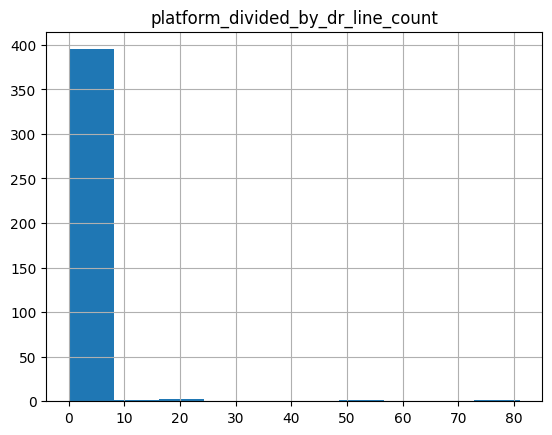

In [ ]:
# Quickly check the distribution of the platform_divided_by_dr_line_count column
merged_df.replace(np.inf, np.nan).hist(column='platform_divided_by_dr_line_count', bins=10)